In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from typing import List
from langchain_core.documents import Document

from langgraph.graph import START,END, StateGraph

c:\Users\mendh\Langchain-Langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

loader = WebBaseLoader(urls)
docs = loader.load()

In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,chunk_overlap = 100
)

chunks = text_splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(
    chunks, embeddings
)

C:\Users\mendh\AppData\Local\Temp\ipykernel_12376\3070854720.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
retriever = vectorstore.as_retriever()
retriever.invoke('What is langgraph')

from langchain.chat_models import init_chat_model
llm = init_chat_model(model_provider="groq",model = "llama-3.1-8b-instant")

In [7]:
class RAGState(BaseModel):
    question:str
    retrived_docs: List[Document] = []
    answer: str = ""


def retrieve_docs(state:RAGState):
    docs = retriever.invoke(state.question)
    return  RAGState(question=state.question, retrieve_docs=docs)

def generate_answer(state: RAGState):
    context = "\n\n".join([doc.page_content for doc in state.retrived_docs]) 
    prompt = f"Answer the question based on the context.\ncontext: {context}\n Question:{state.question}"
    response = llm.invoke(prompt)  
    return {"answer": response.content if hasattr(response, 'content') else response}

    

In [8]:
builder = StateGraph(RAGState)
builder.add_node("retriever",retrieve_docs)
builder.add_node("Generate", generate_answer)

builder.add_edge(START,"retriever")
builder.add_edge("retriever","Generate")
builder.add_edge("Generate",END)

graph = builder.compile()

In [9]:
graph.invoke({"question":'What is langgraph agents'})

{'question': 'What is langgraph agents',
 'retrived_docs': [],
 'answer': 'I couldn\'t find any information about "langgraph agents". It\'s possible that it\'s a term from a specific field or industry that I\'m not familiar with, or it could be a made-up or non-existent term.\n\nHowever, I can try to help you find the answer based on context or provide some possible alternatives:\n\n1. **Graph-based language models**: Langraph is not a widely used term, but graph-based language models are a type of AI model that uses graph structures to represent language relationships. These models can be used for various NLP tasks such as language modeling, text classification, and machine translation.\n2. **Language graph or graph-based NLP**: A language graph is a mathematical representation of language relationships, where nodes represent words or tokens, and edges represent relationships between them. Graph-based NLP models can be used for various tasks such as entity recognition, sentiment analy

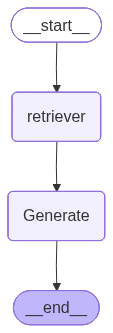

In [10]:
graph